# Chapter 13 example: the permanent as a graphical-model partition function

For a nonnegative matrix $M$, the permanent

$$
\operatorname{perm}(M)=\sum_{\sigma\in S_n}\prod_i M_{i,\sigma(i)}
$$

is the partition function of a perfect-matching graphical model. We compute the permanent exactly for a small matrix and compare it with the Bethe approximation obtained by minimizing the permanent-specific Bethe free energy over the doubly stochastic polytope.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from itertools import product
from scipy.optimize import minimize, linprog

CWD=Path.cwd()
NOTEBOOK_DIR=CWD if CWD.name.startswith('ch') else CWD/'notebooks'/CWD.name if False else CWD
if not (NOTEBOOK_DIR/'figs').exists() and (CWD/'notebooks').exists():
    # infer chapter directory from notebook working directory only when launched at repo root
    raise RuntimeError('Run this notebook from its chapter directory, e.g. notebooks/ch10/.')
FIG_DIR=NOTEBOOK_DIR/'figs'; FIG_DIR.mkdir(parents=True,exist_ok=True)
RNG=np.random.default_rng(577)
NODE_COLOR='#34495e'
plt.rcParams.update({'font.size':14,'axes.titlesize':17,'axes.labelsize':15,'xtick.labelsize':12,'ytick.labelsize':12,'legend.fontsize':12})
def save_figure(fig,stem):
    fig.savefig(FIG_DIR/f'{stem}.pdf',bbox_inches='tight')
    fig.savefig(FIG_DIR/f'{stem}.png',dpi=220,bbox_inches='tight')

In [2]:
from itertools import permutations
M=np.array([[2.0,.7,1.1,.5],[.8,1.8,.6,1.0],[1.2,.5,2.2,.9],[.6,1.0,.8,1.7]])
n=M.shape[0]
def permanent(A): return sum(np.prod([A[i,p[i]] for i in range(n)]) for p in permutations(range(n)))
Z=permanent(M)
def unpack(z): return z.reshape(n,n)
def FB(z):
 B=np.clip(unpack(z),1e-12,1-1e-12)
 return np.sum(B*np.log(B/M)-(1-B)*np.log(1-B))
cons=[]
for i in range(n): cons.append({'type':'eq','fun':lambda z,i=i: unpack(z)[i].sum()-1})
for j in range(n): cons.append({'type':'eq','fun':lambda z,j=j: unpack(z)[:,j].sum()-1})
res=minimize(FB,np.ones(n*n)/n,method='SLSQP',bounds=[(1e-9,1-1e-9)]*(n*n),constraints=cons,options={'ftol':1e-12,'maxiter':3000})
B=unpack(res.x); ZB=np.exp(-res.fun)
print('exact permanent',Z,'Bethe estimate',ZB,'ratio',ZB/Z)

exact permanent 40.3736 Bethe estimate 11.522054379096952 ratio 0.28538585558624824


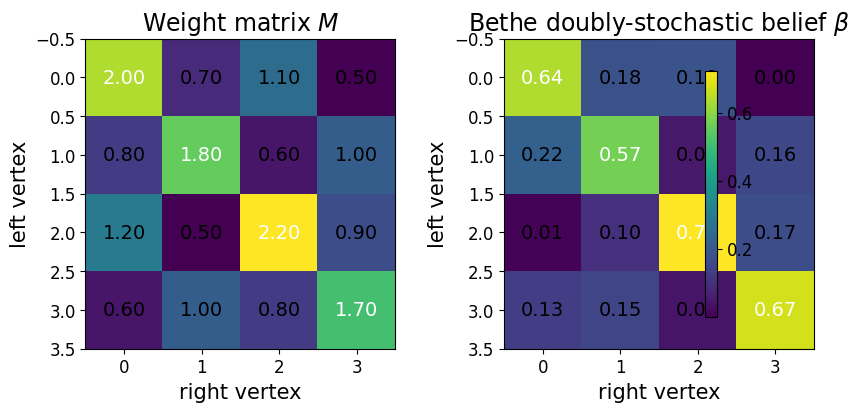

In [3]:
fig,axes=plt.subplots(1,2,figsize=(9.4,4.1));
for ax,A,title in zip(axes,[M,B],['Weight matrix $M$',r'Bethe doubly-stochastic belief $\beta$']):
 im=ax.imshow(A,aspect='equal'); ax.set_title(title); ax.set_xlabel('right vertex'); ax.set_ylabel('left vertex')
 for i in range(n):
  for j in range(n): ax.text(j,i,f'{A[i,j]:.2f}',ha='center',va='center',color='white' if A[i,j]>.55*A.max() else 'black')
fig.colorbar(im,ax=axes.ravel().tolist(),shrink=.78); fig.subplots_adjust(right=.9,wspace=.35); save_figure(fig,'ch13_01_matrix_and_bethe_belief'); plt.show()

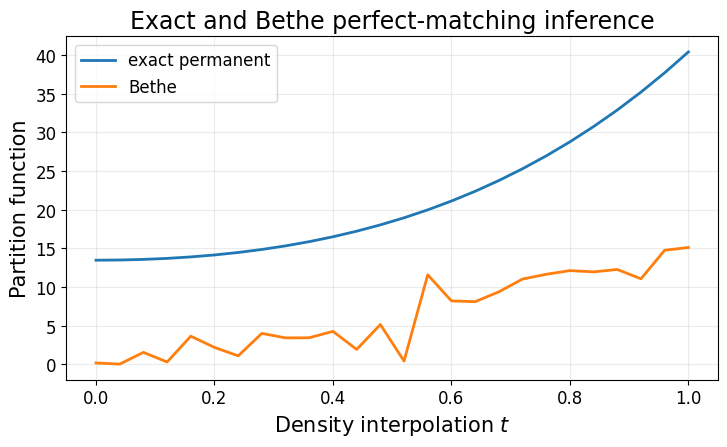

In [4]:
# Interpolate from a nearly diagonal to a dense matrix.
ts=np.linspace(0,1,26); exact=[]; bethe=[]
D=np.diag(np.diag(M)); Dense=M
for t in ts:
 A=(1-t)*D+t*Dense+1e-6*np.ones_like(M)
 exact.append(permanent(A))
 def F(z):
  Q=np.clip(z.reshape(n,n),1e-12,1-1e-12); return np.sum(Q*np.log(Q/A)-(1-Q)*np.log(1-Q))
 r=minimize(F,np.ones(n*n)/n,method='SLSQP',bounds=[(1e-9,1-1e-9)]*(n*n),constraints=cons,options={'ftol':1e-10,'maxiter':1500}); bethe.append(np.exp(-r.fun))
fig,ax=plt.subplots(figsize=(7.5,4.7)); ax.plot(ts,exact,label='exact permanent',linewidth=2); ax.plot(ts,bethe,label='Bethe',linewidth=2); ax.set_xlabel('Density interpolation $t$'); ax.set_ylabel('Partition function'); ax.set_title('Exact and Bethe perfect-matching inference'); ax.grid(alpha=.25); ax.legend(); fig.tight_layout(); save_figure(fig,'ch13_01_exact_vs_bethe_permanent'); plt.show()

## Exercises

1. Replace $M$ by a permutation matrix plus weak noise. Explain why the Bethe approximation becomes accurate.
2. Compare the Bethe estimate with the simple mean-field-like approximation obtained from a uniform doubly stochastic matrix.
3. **Challenge.** Implement a fractional free energy and optimize the fractional parameter jointly or by a one-dimensional sweep.